# 3D morphometry & biomass plots of virus-infected *Guinardia delicatula* — from the authors' own R scripts

**Paper:** Walde, Camplong, de Vargas, Baudoux & Simon (2022), *Viral infection impacts the 3D subcellular structure of the abundant marine diatom Guinardia delicatula*, bioRxiv v1, DOI [10.1101/2022.09.06.505714](https://doi.org/10.1101/2022.09.06.505714)

**Author code:** [mariescopy/Guinardia_ViralInfection](https://github.com/mariescopy/Guinardia_ViralInfection) @ commit `ed673c0f6cdad873c5dd3b96d4e7b690bce88b14` (GPL-3.0)

**Scope — PARTIAL DEMONSTRATION (executed):** This notebook re-runs the paper's *quantitative analysis and plotting* stage: it downloads the authors' intermediate Excel tables (`3D_Morphometry.xlsx`, `Biovolumes_biomass.xlsx`, `SummaryQuantifications.xlsx`) from the pinned commit and executes **the authors' own R scripts** (with documented minimal adaptations) to regenerate figure groups in the style of paper Figures 1, 3, 4 and 5. It does **not** reproduce the wet-lab infection experiment, the Leica confocal acquisition, or the FIJI image processing of raw LIF files (BioStudies S-BIAD534). One-example runs do not verify the paper's dataset-level claims.

**実行スコープ（部分再現・実行済み）:** 論文の定量解析・プロット段階を、著者自身の R スクリプトと中間 Excel テーブルで再実行します。湿式実験・共焦点撮像・FIJI 画像解析（生 LIF 画像）は対象外です。

**AI-assisted adaptation notice:** The R scripts are the authors' own code copied from the pinned commit; this Colab launcher was not provided by the authors. Small documented adaptations (paths, removed sections whose input files are absent from the repository, two naming bugs, PNG capture) are labeled inline. The executed example was validated, but untested behavior is not guaranteed.

**Runtime: CPU only** (no GPU needed — pure R data/plotting). Select **Runtime → Change runtime type → CPU**, then *Run all*. Expected: ~5 minutes, ~200 MB of package downloads plus ~200 KB of data.

In [ ]:
import subprocess, sys, platform

r = subprocess.run(["Rscript", "--version"], capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError("Rscript is not available in this runtime. Select a standard "
                       "Colab CPU runtime (R is preinstalled there) and re-run.")
print(r.stdout.strip() or r.stderr.strip())
print("Kernel Python:", sys.version.split()[0], "| OS:", platform.platform())

Rscript (R) version 4.6.1 (2026-06-24)
Kernel Python: 3.13.15 | OS: Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Environment & dependencies

The authors' scripts need `readxl`, `ggplot2`, `data.table`, `RColorBrewer`, `cowplot` and `gridExtra`.
We install prebuilt Ubuntu (noble) binaries from the Posit Public Package Manager to avoid long
compiles; `ggplot2`/`grid`/`data.table` are already present in Colab's R but are pinned here for reproducibility.

**依存パッケージの導入。** コンパイルを避けるため Posit の Ubuntu バイナリリポジトリからインストールします（数分）。

In [ ]:
import subprocess

PKGS = ["readxl", "ggplot2", "data.table", "RColorBrewer", "cowplot", "gridExtra"]
REPO = "https://packagemanager.posit.co/cran/__linux__/noble/latest"

r_code = (
    f'options(repos = c(POSIT = "{REPO}"))\n'
    f'pkgs <- c({",".join(repr(p) for p in PKGS)})\n'
    "install.packages(pkgs)\n"
    "ip <- rownames(installed.packages())\n"
    'cat("installed:", paste(intersect(ip, pkgs), collapse=", "), "\\n")\n'
    "stopifnot(all(pkgs %in% ip))\n"
)
r = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True, timeout=1800)
print((r.stdout or "")[-1500:])
if r.returncode != 0:
    print((r.stderr or "")[-2000:])
    raise RuntimeError("R package installation failed; see output above.")

inux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG      -fvisibility=hidden  -fopenmp  -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c wrappers.c -o wrappers.o
x86_64-linux-gnu-gcc -std=gnu2x -shared -L/usr/lib/R/lib -Wl,-Bsymbolic-functions -flto=auto -ffat-lto-objects -Wl,-z,relro -o data.table.so assign.o between.o bmerge.o chmatch.o cj.o coalesce.o deleterows.o dogroups.o fastmean.o fcast.o fifelse.o fmelt.o forder.o frank.o fread.o freadR.o froll.o frollR.o frolladaptive.o frollapply.o fsort.o fwrite.o fwriteR.o gsumm.o hash.o idatetime.o ijoin.o init.o inrange.o mergelist.o nafill.o negate.o nqrecreateindices.o openmp-utils.o programming.o quickselect.o rbindlist.o reorder.o shellsort.o

## 2. Input acquisition with pinned provenance

All inputs are downloaded **inside Colab** from the pinned author commit
`ed673c0f6cdad873c5dd3b96d4e7b690bce88b14`. Each file's git blob SHA-1 is recomputed and asserted,
so a wrong or mutated download fails loudly. Nothing is fetched on the host.

**入力データは pinned コミットから Colab 内でダウンロードし、git blob SHA-1 で検証します。

In [ ]:
import hashlib, pathlib

COMMIT = "ed673c0f6cdad873c5dd3b96d4e7b690bce88b14"
BASE = "https://raw.githubusercontent.com/mariescopy/Guinardia_ViralInfection/ed673c0f6cdad873c5dd3b96d4e7b690bce88b14"

# (filename, expected git blob SHA-1, role)
FILES = [
    ("3D_Morphometry.xlsx",      "011d65af7f4e540161ccf071cd2fd26e32ca88a3", "data: 3D organelle morphometry (input of plotting_3DMorphometry.R)"),
    ("Biovolumes_biomass.xlsx",  "76ced2698d59c024fa507d8173b04db45379f948", "data: biovolume/biomass tables (input of plotting_Biovolumes.R)"),
    ("SummaryQuantifications.xlsx", "ea5a59334dbdf88194e125b9aea4009de83efe48", "data: physiology/counts summary (input of plotting_Summary.R)"),
    ("plotting_3DMorphometry.R", "fc1a428f7fc4ee1fa4444da732987c1dc62744b0", "author code"),
    ("plotting_Biovolumes.R",    "c42d597f176e513030a9eb047364082f6ce0c333", "author code"),
    ("plotting_Summary.R",       "21a2f5c76639c0ae33609059f63bb67f3d684358", "author code"),
]

pathlib.Path("/content/data").mkdir(parents=True, exist_ok=True)
pathlib.Path("/content/data/author_scripts").mkdir(exist_ok=True)

def blob_sha1(content: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(content) + content).hexdigest()

for fname, sha, role in FILES:
    dest = pathlib.Path("/content/data", fname) if fname.endswith(".xlsx") else pathlib.Path("/content/data/author_scripts", fname)
    import urllib.request
    with urllib.request.urlopen(f"{BASE}/{fname}", timeout=60) as resp:
        content = resp.read()
    got = blob_sha1(content)
    assert got == sha, f"{fname}: SHA-1 mismatch ({got} != {sha})"
    dest.write_bytes(content)
    print(f"OK  {fname:32s} {len(content):>8d} B  blob {got[:12]}…  ({role})")

OK  3D_Morphometry.xlsx                 57353 B  blob 011d65af7f4e…  (data: 3D organelle morphometry (input of plotting_3DMorphometry.R))
OK  Biovolumes_biomass.xlsx            107992 B  blob 76ced2698d59…  (data: biovolume/biomass tables (input of plotting_Biovolumes.R))


OK  SummaryQuantifications.xlsx         11433 B  blob ea5a59334dbd…  (data: physiology/counts summary (input of plotting_Summary.R))
OK  plotting_3DMorphometry.R             5323 B  blob fc1a428f7fc4…  (author code)


OK  plotting_Biovolumes.R                7532 B  blob c42d597f176e…  (author code)
OK  plotting_Summary.R                   5287 B  blob 21a2f5c76639…  (author code)


## 3. Input preview

Quick structural check of the Excel tables (sheet names, dimensions) before analysis.

**入力テーブルの構造確認（シート名・サイズ）。**

In [ ]:
script = r"""
options(width = 120)
for (f in c("3D_Morphometry.xlsx", "Biovolumes_biomass.xlsx", "SummaryQuantifications.xlsx")) {
  cat("==", f, "==\n")
  for (s in readxl::excel_sheets(file.path("/content/data", f))) {
    d <- readxl::read_excel(file.path("/content/data", f), sheet = s)
    cat(sprintf("  sheet %-22s %4d rows x %3d cols\n", s, nrow(d), ncol(d)))
  }
}
"""
pathlib.Path("/content/data/inspect.R").write_text(script)
r = subprocess.run(["Rscript", "/content/data/inspect.R"], capture_output=True, text=True, timeout=300)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-2000:]); raise RuntimeError("Input inspection failed.")

== 3D_Morphometry.xlsx ==
  sheet Chl_Sphericity           60 rows x   8 cols
  sheet Chl_Volume               60 rows x   8 cols
  sheet Nuc_Volume               60 rows x   8 cols
  sheet Plots                     0 rows x   0 cols
  sheet Chl_Sphericity_con       26 rows x   8 cols
  sheet Chl_Volume_con           26 rows x   8 cols
  sheet Nuc_Vol_con              26 rows x   8 cols
  sheet Imaris                   17 rows x   8 cols
== Biovolumes_biomass.xlsx ==
  sheet Summary                  18 rows x  34 cols
  sheet Summary_Tidy             16 rows x  27 cols
  sheet All_tidy                303 rows x   8 cols
  sheet t0_control               19 rows x   5 cols
  sheet t1_control               27 rows x   5 cols
  sheet t2_control               21 rows x   5 cols
  sheet t3_control               19 rows x   5 cols
  sheet t4_control               24 rows x   6 cols
  sheet t5_control               23 rows x   5 cols
  sheet t6_control               24 rows x   5 cols
  sheet 

## 4. Figure 4 & Figure 5 data: 3D organelle morphometry (authors' `plotting_3DMorphometry.R`)

This script reads the chloroplast sphericity / chloroplast volume / nucleus volume tables
(`3D_Morphometry.xlsx`, sheets `Chl_Sphericity(_con)`, `Chl_Volume(_con)`, `Nuc_Volume(_con)`) and
draws the paper-Figure-4-style boxplots of infected vs control cultures over time.

**Documented adaptations** (original is otherwise verbatim from commit `ed673c0`):
1. `stwd("S:/Quantification//")` → files read from `/content/data` (the authors' local drive path).
2. `3D_Morphometry_noNA.xlsx` is **absent from the pinned repository**, so the per-timepoint
   `t.test()`/`lm()` biostatistics section is omitted (it reads a file that was never committed).
3. `melt()` keeps the added `file` label column as an id variable (otherwise it pollutes the value axis).
4. Figures are written to PNG via a small `save_grob()`/`arrangeGrob()` helper instead of interactive drawing.

**著者のスクリプトをほぼそのまま実行します。欠落入力（`3D_Morphometry_noNA.xlsx`）に依存する統計検定部のみ省略し、経路・PNG 出力のみ最小限変更しています。**

In [ ]:
pathlib.Path("/content/data/plotting_3DMorphometry_adapted.R").write_text(
    '## Adapted from mariescopy/Guinardia_ViralInfection @ ed673c0f6cdad873c5dd3b96d4e7b690bce88b14\n## Original: plotting_3DMorphometry.R (GPL-3.0). Adaptations: /content paths; biostatistics section\n## omitted (3D_Morphometry_noNA.xlsx absent from repo); melt keeps \'file\' as id; PNG capture helper.\noptions(width = 120)\nsuppressPackageStartupMessages({\n  library(readxl); library(ggplot2); library(data.table); library(RColorBrewer)\n  library(gridExtra); library(grid)\n})\nsetwd("/content/data")\nsave_grob <- function(p, file, w = 12, h = 7) {\n  png(file, width = w, height = h, units = "in", res = 150)\n  if (inherits(p, "ggplot")) print(p) else grid.draw(p)\n  dev.off()\n}\n\n# Opening the data\n# infected samples\nchl_sph     <- read_excel("3D_Morphometry.xlsx", sheet = "Chl_Sphericity", na = "")\nchl_vol     <- read_excel("3D_Morphometry.xlsx", sheet = "Chl_Volume",     na = "")\nnuc_vol     <- read_excel("3D_Morphometry.xlsx", sheet = "Nuc_Volume",     na = "")\n# control samples\nchl_sph_con <- read_excel("3D_Morphometry.xlsx", sheet = "Chl_Sphericity_con", na = "")\nchl_vol_con <- read_excel("3D_Morphometry.xlsx", sheet = "Chl_Volume_con",     na = "")\nnuc_vol_con <- read_excel("3D_Morphometry.xlsx", sheet = "Nuc_Vol_con",        na = "")\n\n# removing first (empty) row from \'Chl_Volume\', although row 55 from all datasets is empty\nchl_vol <- chl_vol[-1, ]\n\n# Adding the name of the file as a variable\nchl_sph$file     <- "Chloroplast sphericity [0,1]"\nchl_vol$file     <- "Chloroplast volume [um^3]"\nnuc_vol$file     <- "Nuclei volume [um^3]"\nchl_sph_con$file <- "Chloroplast sphericity [0,1]"\nchl_vol_con$file <- "Chloroplast volume [um^3]"\nnuc_vol_con$file <- "Nuclei volume [um^3]"\n\n# Melting the datasets into one column (adaptation: keep \'file\' as id variable)\nchl_sph     <- melt(as.data.table(chl_sph),     id.vars = "file")\nchl_vol     <- melt(as.data.table(chl_vol),     id.vars = "file")\nnuc_vol     <- melt(as.data.table(nuc_vol),     id.vars = "file")\nchl_sph_con <- melt(as.data.table(chl_sph_con), id.vars = "file")\nchl_vol_con <- melt(as.data.table(chl_vol_con), id.vars = "file")\nnuc_vol_con <- melt(as.data.table(nuc_vol_con), id.vars = "file")\n\n## --- BIOSTATISTICS section omitted: requires 3D_Morphometry_noNA.xlsx, which is not in the repo. ---\n\n# PLOTTING — Figure 4: Morphological changes\n# infected\np_chl_sph_inf <- ggplot(chl_sph, aes(x = variable, y = value, fill = variable)) +\n  geom_jitter(alpha = 0.2, width = 0.1) +\n  geom_boxplot(alpha = 0.7, outlier.shape = NA) +\n  labs(title = "Chloroplast Sphericity", x = "", y = "Sphericity [0;1]") +\n  theme_minimal() +\n  theme(legend.position = "none", plot.title = element_text(face = "bold")) + ylim(0, 0.6) +\n  scale_fill_brewer(palette = "RdPu", direction = -1)\n\np_chl_vol_inf <- ggplot(chl_vol, aes(x = variable, y = value, fill = variable)) +\n  geom_jitter(alpha = 0.2, width = 0.1) +\n  geom_boxplot(alpha = 0.7, outlier.shape = NA) +\n  labs(title = "Chloroplast Volume", x = "", y = "Volume [um^3]") +\n  theme_minimal() +\n  theme(legend.position = "none", plot.title = element_text(face = "bold")) + ylim(0, 1800) +\n  scale_fill_brewer(palette = "RdPu", direction = -1)\n\np_nuc_vol_inf <- ggplot(nuc_vol, aes(x = variable, y = value, fill = variable)) +\n  geom_jitter(alpha = 0.2, width = 0.1) +\n  geom_boxplot(alpha = 0.7, outlier.shape = NA) +\n  labs(title = "Nucleus Volume", x = "", y = "Volume [um^3]") +\n  theme_minimal() +\n  theme(legend.position = "none", plot.title = element_text(face = "bold")) + ylim(0, 170) +\n  scale_fill_brewer(palette = "Blues", direction = -1)\n\n# control\np_chl_sph_con <- ggplot(chl_sph_con, aes(x = variable, y = value, fill = variable)) +\n  geom_jitter(alpha = 0.2, width = 0.1) +\n  geom_boxplot(alpha = 0.7, outlier.shape = NA) +\n  labs(x = "Time post infection", y = "Sphericity [0;1]") +\n  theme_minimal() +\n  theme(legend.position = "none", plot.title = element_text(face = "bold")) + ylim(0, 0.6) +\n  scale_fill_brewer(palette = "RdPu", direction = -1)\n\np_chl_vol_con <- ggplot(chl_vol_con, aes(x = variable, y = value, fill = variable)) +\n  geom_jitter(alpha = 0.2, width = 0.1) +\n  geom_boxplot(alpha = 0.7, outlier.shape = NA) +\n  labs(x = "Time post infection", y = "Volume [um^3]") +\n  theme_minimal() +\n  theme(legend.position = "none", plot.title = element_text(face = "bold")) + ylim(0, 1800) +\n  scale_fill_brewer(palette = "RdPu", direction = -1)\n\np_nuc_vol_con <- ggplot(nuc_vol_con, aes(x = variable, y = value, fill = variable)) +\n  geom_jitter(alpha = 0.2, width = 0.1) +\n  geom_boxplot(alpha = 0.7, outlier.shape = NA) +\n  labs(x = "Time post infection", y = "Volume [um^3]") +\n  theme_minimal() +\n  theme(legend.position = "none", plot.title = element_text(face = "bold")) + ylim(0, 170) +\n  scale_fill_brewer(palette = "Blues", direction = -1)\n\n# Figure 4-style combined panel (infected row above, control row below) — captured to PNG\nfig4 <- arrangeGrob(p_chl_sph_inf, p_chl_vol_inf, p_nuc_vol_inf,\n                    p_chl_sph_con, p_chl_vol_con, p_nuc_vol_con, nrow = 2)\nsave_grob(fig4, "/content/data/fig4_morphology.png")\n\ncat("Figure 4-style panel written.\\n")\ncat("Infected chloroplast sphericity n =", nrow(chl_sph), "values;",\n    "control n =", nrow(chl_sph_con), "values.\\n")', encoding="utf-8")
r = subprocess.run(["Rscript", "/content/data/plotting_3DMorphometry_adapted.R"], capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("plotting_3DMorphometry.R (adapted) failed; see output above.")

pdf 
  2 
Figure 4-style panel written.
Infected chloroplast sphericity n = 480 values; control n = 208 values.



Rendered Figure-4-style panel (top: infected, bottom: control; chloroplast sphericity, chloroplast volume, nucleus volume over time points):

**図 4 相当のパネル（上: 感染群、下: 対照群）。**

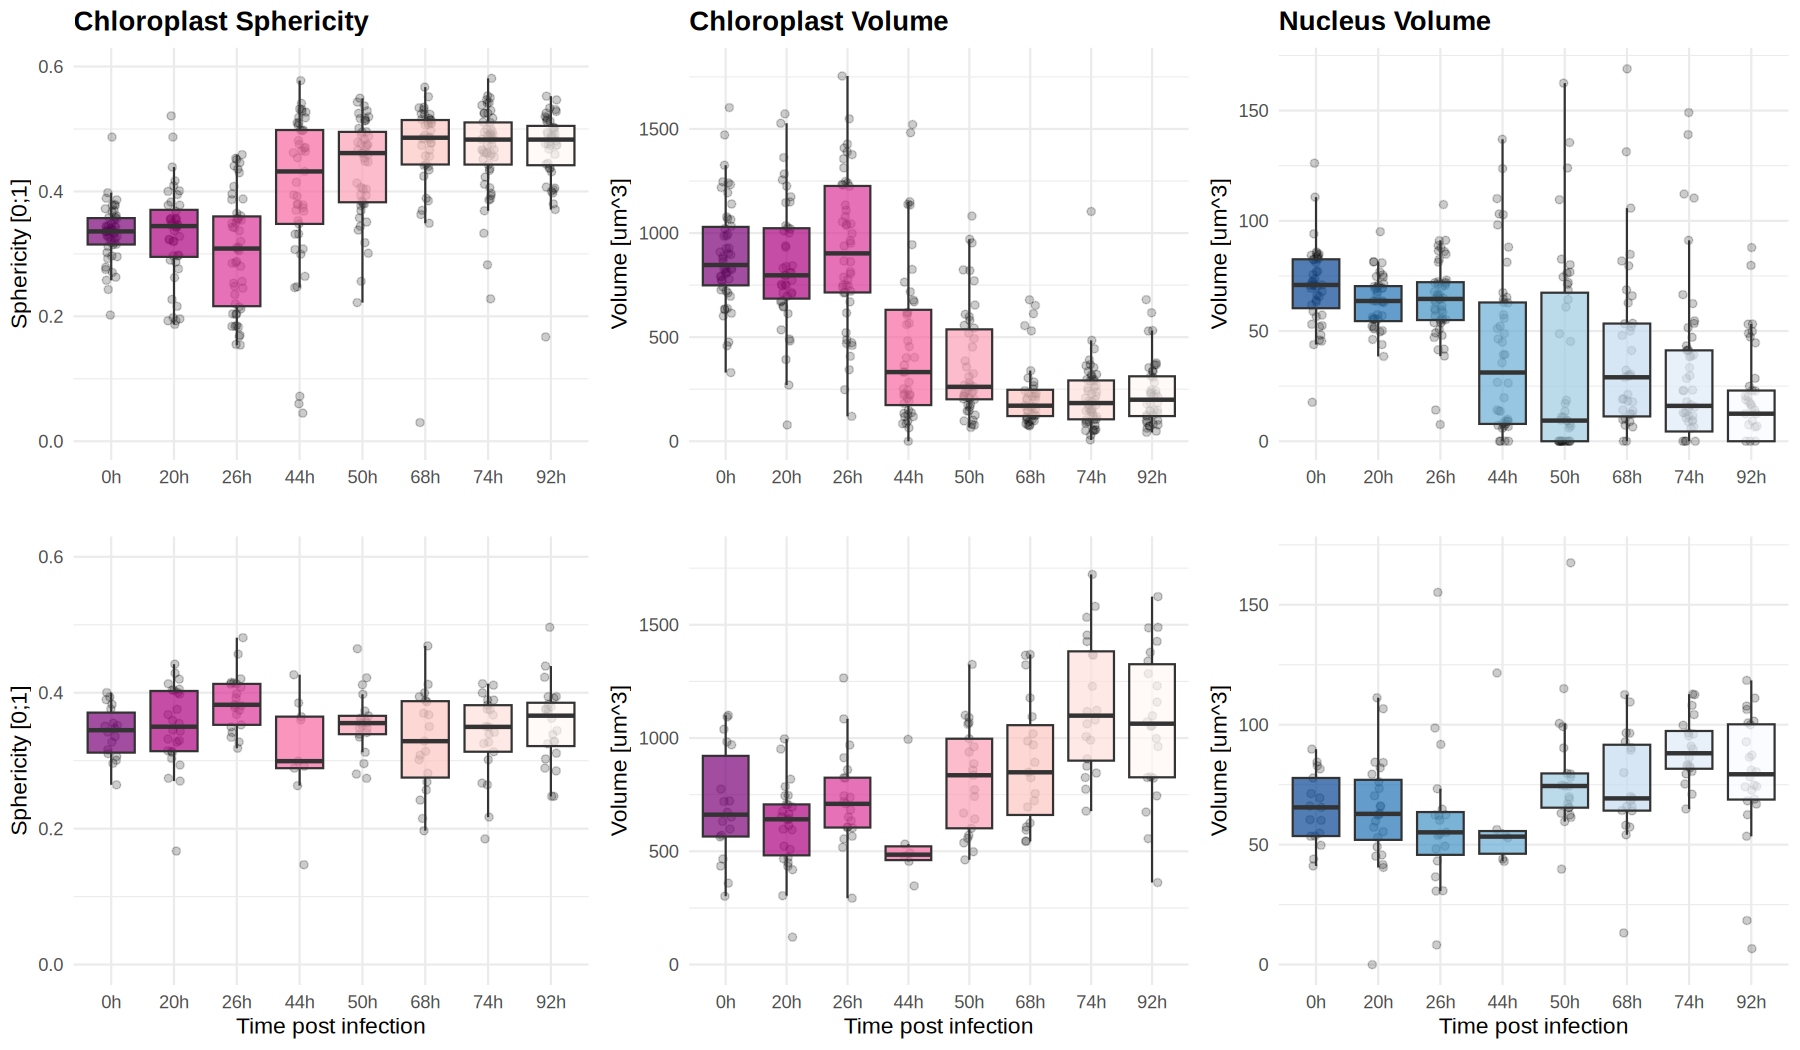

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/data/fig4_morphology.png"))

## 5. Biovolume & biomass time series (authors' `plotting_Biovolumes.R`)

Reads `Biovolumes_biomass.xlsx` (sheet 2: per-timepoint medians, abundances, biomass; sheet 3:
tidy per-cell biovolumes) and draws the paper-Figure-5-style biovolume/biomass panels plus the
cell abundance and growth-rate series.

**Documented adaptations:**
1. `setwd()`/`here()` paths → `/content/data`.
2. The final combined figure references `p2b_FvFm`, which the authors define in a *different* script
   (`plotting_Summary.R`); that cross-script reference is dropped here — the Fv/Fm panel is rendered
   in the next section instead.
3. The never-assigned "Biomass median" plot is assigned to `p2a_biomassmedian` so it can be drawn.
4. PNG capture helper as above.

**著者の `plotting_Biovolumes.R` を実行します（他スクリプト由来の `p2b_FvFm` 参照のみ除去）。**

In [ ]:
pathlib.Path("/content/data/plotting_Biovolumes_adapted.R").write_text(
    '## Adapted from mariescopy/Guinardia_ViralInfection @ ed673c0f6cdad873c5dd3b96d4e7b690bce88b14\n## Original: plotting_Biovolumes.R (GPL-3.0). Adaptations: /content paths; cross-script p2b_FvFm\n## reference removed; unassigned biomass-median plot assigned; PNG capture helper.\noptions(width = 120)\nsuppressPackageStartupMessages({\n  library(readxl); library(ggplot2); library(data.table); library(RColorBrewer); library(grid)\n})\nsetwd("/content/data")\nsave_grob <- function(p, file, w = 8, h = 6) {\n  png(file, width = w, height = h, units = "in", res = 150)\n  if (inherits(p, "ggplot")) print(p) else grid.draw(p)\n  dev.off()\n}\n\n# Opening the data\nbiovolume_data <- read_excel("Biovolumes_biomass.xlsx", sheet = 2, na = "")\ncolnames(biovolume_data)\nbiovolume_tidy <- read_excel("Biovolumes_biomass.xlsx", sheet = 3, na = "")\ncolnames(biovolume_tidy)\nbiovolume_tidy$hpi <- as.factor(biovolume_tidy$hpi)\n\n# PLOTTING\n# Cell Biovolumes & Biomass (paper Fig. 5, with secondary C-biomass axis)\np5_biovolumes_biomass <- ggplot(biovolume_tidy) + aes(hpi, volume_um3, color = Culture, fill = Culture, alpha = Culture) +\n  geom_jitter(width = 0.15) +\n  geom_boxplot(outlier.shape = NA) +\n  scale_y_continuous("Biovolume [um^3]\\n", sec.axis = sec_axis(~10^(0.76 * log10(.)) - 0.352, name = "Biomass [pg C]\\n")) +\n  labs(title = "Measured biovolumes & estimated C biomass per cell", x = "Time post infection (hours)") +\n  scale_fill_manual(values = c("black", "red2")) +\n  scale_alpha_manual(values = c(0.15, 0.3)) +\n  scale_colour_manual(values = c("black", "red2")) +\n  theme_bw() +\n  coord_cartesian(ylim = c(0, 3000)) +\n  theme(legend.position = "bottom", plot.title = element_text(face = "bold"))\nsave_grob(p5_biovolumes_biomass, "/content/data/fig5_biovolumes_biomass.png")\n\n# only cell biovolumes\np4_biovolumes <- ggplot(biovolume_tidy) + aes(hpi, volume_um3, color = Culture, fill = Culture, alpha = Culture) +\n  geom_jitter(width = 0.15) +\n  geom_boxplot(outlier.shape = NA) +\n  scale_y_continuous("Biovolume [um^3]\\n") +\n  labs(title = "Measured biovolumes & estimated C biomass per cell", x = "Time post infection (hours)") +\n  scale_fill_manual(values = c("gray50", "black")) +\n  scale_alpha_manual(values = c(0.15, 0.3)) +\n  scale_colour_manual(values = c("gray50", "black")) +\n  theme_minimal() +\n  coord_cartesian(ylim = c(0, 3000)) +\n  theme(legend.position = "bottom", plot.title = element_text(face = "bold"))\n\n# Measured abundances\np1a_abundance_counts <- ggplot(biovolume_data) + aes(hpi, Abundance_count, color = Culture, linetype = Culture) +\n  geom_point() +\n  geom_line(size = 1) +\n  labs(title = "Cell abundances", x = "", y = "Cells / mL\\n") +\n  scale_colour_manual(values = c("gray50", "red2")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  theme_bw() + theme(legend.position = "none", plot.title = element_text(face = "bold"))\n\n# Growth rates\np1b_abundance_rates <- ggplot(biovolume_data) + aes(hpi, Abundance_rate, color = Culture, linetype = Culture) +\n  geom_point() +\n  geom_line(size = 1) +\n  geom_hline(aes(yintercept = 0)) +\n  labs(title = "Growth rate", x = "Time post infection (hours)", y = "Cells / (mL h)\\n") +\n  scale_colour_manual(values = c("gray50", "red2")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  theme_bw() + theme(legend.position = "bottom", plot.title = element_text(face = "bold"))\nsave_grob(rbind(ggplotGrob(p1a_abundance_counts), ggplotGrob(p1b_abundance_rates), size = "last"),\n          "/content/data/fig5_abundance_growth.png", w = 8, h = 7)\n\n# Biomass median (assigned so it can be drawn — unassigned in the original)\np2a_biomassmedian <- ggplot(biovolume_data) + aes(hpi, Biomass_ngLiter, color = Culture, linetype = Culture) +\n  geom_point() +\n  geom_line(size = 1) +\n  labs(title = "Estimated Biomass", x = "", y = "Biomass [ng C / L]\\n") +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  theme_bw() + theme(legend.position = "none", plot.title = element_text(face = "bold"))\n\n# Biomass rate\np2b_biomassmedian <- ggplot(biovolume_data) + aes(hpi, BiomassRate, color = Culture, linetype = Culture) +\n  geom_point() +\n  geom_line(size = 1) +\n  geom_hline(aes(yintercept = 0)) +\n  labs(x = "Time post infection (hours)", y = "Biomass rate [pg C / L h]\\n") +\n  scale_colour_manual(values = c("gray50", "red2")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  theme_bw() + theme(legend.position = "bottom", plot.title = element_text(face = "bold"))\nsave_grob(rbind(ggplotGrob(p2a_biomassmedian), ggplotGrob(p2b_biomassmedian), size = "last"),\n          "/content/data/fig5_biomass_rate.png", w = 8, h = 7)\n\n# Biovolume\np3a_biovolume <- ggplot(biovolume_data) +\n  aes(x = hpi, y = VolumeMedian, color = Culture, fill = Culture) +\n  geom_point() +\n  geom_line(aes(linetype = Culture), size = 1) +\n  geom_ribbon(aes(ymin = VolumeMedian - VolumeStdDev, ymax = VolumeMedian + VolumeStdDev), linetype = 0, alpha = 0.15) +\n  labs(title = "Measured Cell Biovolumes", x = "", y = "Volume\\n[um^3]\\n") +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_colour_manual(values = c("gray75", "black")) +\n  scale_fill_manual(values = c("gray50", "gray50")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  coord_cartesian(ylim = c(0, 2500)) +\n  theme_minimal() + theme(legend.position = "none", plot.title = element_text(face = "bold"))\n# Biomass\np3a_biomassmedian <- ggplot(biovolume_data) +\n  aes(x = hpi, y = Biomass_ngLiter, color = Culture, fill = Culture) +\n  geom_point() +\n  geom_line(aes(linetype = Culture), size = 1) +\n  geom_ribbon(aes(ymin = Biomass_ngLiter - Biomass_ngLiter_StDv, ymax = Biomass_ngLiter + Biomass_ngLiter_StDv), linetype = 0, alpha = 0.15) +\n  labs(title = "Estimated Total Biomass", x = "", y = "Biomass\\n[ng C / L]\\n") +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_colour_manual(values = c("gray50", "black")) +\n  scale_fill_manual(values = c("gray50", "gray75")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  theme_bw() + theme(legend.position = "bottom")\n\n# Chloroplasts median\np3b_chlmedian <- ggplot(biovolume_data) +\n  aes(x = hpi, y = ChloroplastsMedian, color = Culture, fill = Culture) +\n  geom_point() +\n  geom_line(aes(linetype = Culture), size = 1) +\n  geom_ribbon(aes(ymax = ChloroplastsMedian + ChloroplastStDv, ymin = ChloroplastsMedian - ChloroplastStDv), linetype = 0, alpha = 0.15) +\n  labs(title = "Chloroplast size", x = "", y = "Volume\\n[um^3]\\n") +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_colour_manual(values = c("gray50", "purple4")) +\n  scale_fill_manual(values = c("gray50", "purple4")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  theme_bw() + theme(legend.position = "none", plot.title = element_text(face = "bold"))\n\n# Nuclei median\np3c_nucmedian <- ggplot(biovolume_data) +\n  aes(x = hpi, y = NucleiMedian, color = Culture, fill = Culture) +\n  geom_point() +\n  geom_line(aes(linetype = Culture), size = 1) +\n  geom_ribbon(aes(ymax = NucleiMedian + NucleiStDev, ymin = NucleiMedian - NucleiStDev), linetype = 0, alpha = 0.15) +\n  labs(title = "Nuclei size", x = "", y = "Volume\\n[um^3]\\n") +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_colour_manual(values = c("gray50", "blue2")) +\n  scale_fill_manual(values = c("gray50", "blue2")) +\n  scale_linetype_manual(values = c("longdash", "solid")) +\n  coord_cartesian(ylim = c(0, 150)) +\n  theme_bw() + theme(legend.position = "none", plot.title = element_text(face = "bold"))\n\n# Chloroplasts proportion\np3d_chlpercent <- ggplot(biovolume_data) +\n  aes(hpi, ChloroplastsPercent, color = Culture) +\n  geom_point() +\n  geom_line(aes(linetype = Culture), size = 1) +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_colour_manual(values = c("purple4", "purple4")) +\n  scale_linetype_manual(values = c("dashed", "solid")) +\n  labs(title = "Chloroplast proportion", x = "\\nTime post infection (hours)", y = "Median %\\nof biovolume\\n") +\n  theme_minimal() + theme(legend.position = "bottom", plot.title = element_text(face = "bold")) + ylim(0, 100)\n\n###########################################\n# Figure 5: Cell Biovolumes & Biomass (adaptation: p2b_FvFm belongs to plotting_Summary.R and is\n# not re-defined here, so the combined panel is biovolume + chloroplast proportion)\nsave_grob(rbind(ggplotGrob(p3a_biovolume), ggplotGrob(p3a_biomassmedian),\n                ggplotGrob(p3c_nucmedian), ggplotGrob(p3b_chlmedian), ggplotGrob(p3d_chlpercent),\n                size = "last"),\n          "/content/data/fig5_biovolume_panels.png", w = 8, h = 12)\n\ncat("Biovolume/biomass figures written.\\n")', encoding="utf-8")
r = subprocess.run(["Rscript", "/content/data/plotting_Biovolumes_adapted.R"], capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("plotting_Biovolumes.R (adapted) failed; see output above.")

 [1] "Culture"              "Timepoint"            "hpi"                  "ViralTiter_count"     "ViralTiter_rate"     
 [6] "Abundance_count"      "Abundance_rate"       "Abundance_rate_day"   "Abundance_rate_total" "DiameterMedian"      
[11] "DiameterStdDev"       "LengthMedian"         "LengthStdDev"         "VolumeMedian"         "VolumeStdDev"        
[16] "Biomass_cell"         "Biomass_cell_StDv"    "Biomass_pgLiter"      "Biomass_ngLiter"      "Biomass_ngLiter_StDv"
[21] "BiomassRate"          "ChloroplastsMedian"   "ChloroplastStDv"      "NucleiMedian"         "NucleiStDev"         
[26] "ChloroplastsPercent"  "NucleiPercent"       
[1] "timepoint"   "Culture"     "hpi"         "cell_num"    "diameter_um" "length_um"   "volume_um3"  "C_biomass"  
null device 
          1 
null device 
          1 
null device 
          1 
null device 
          1 
Biovolume/biomass figures written.



Rendered biovolume/biomass panels:

**バイオボリューム／バイオマスのパネル群。**

fig5_biovolumes_biomass.png


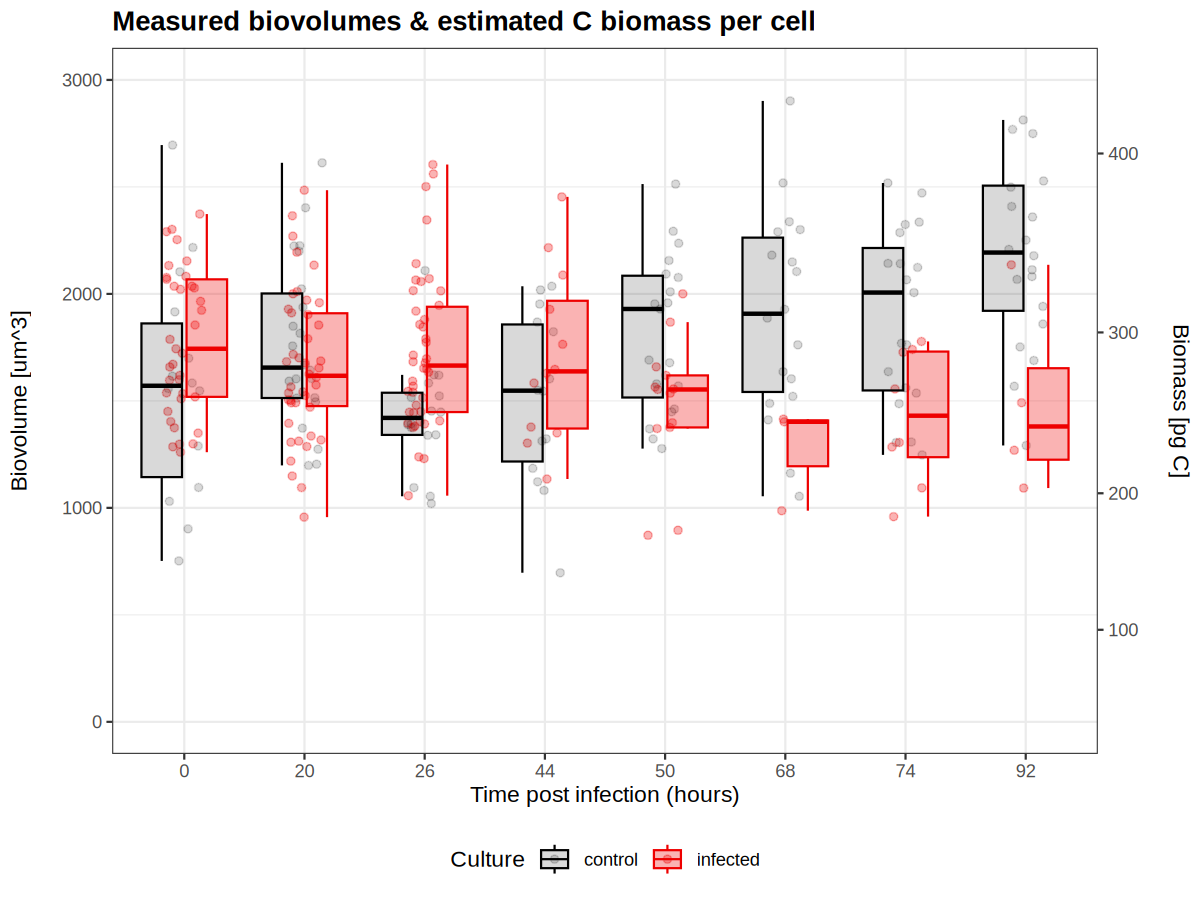

fig5_abundance_growth.png


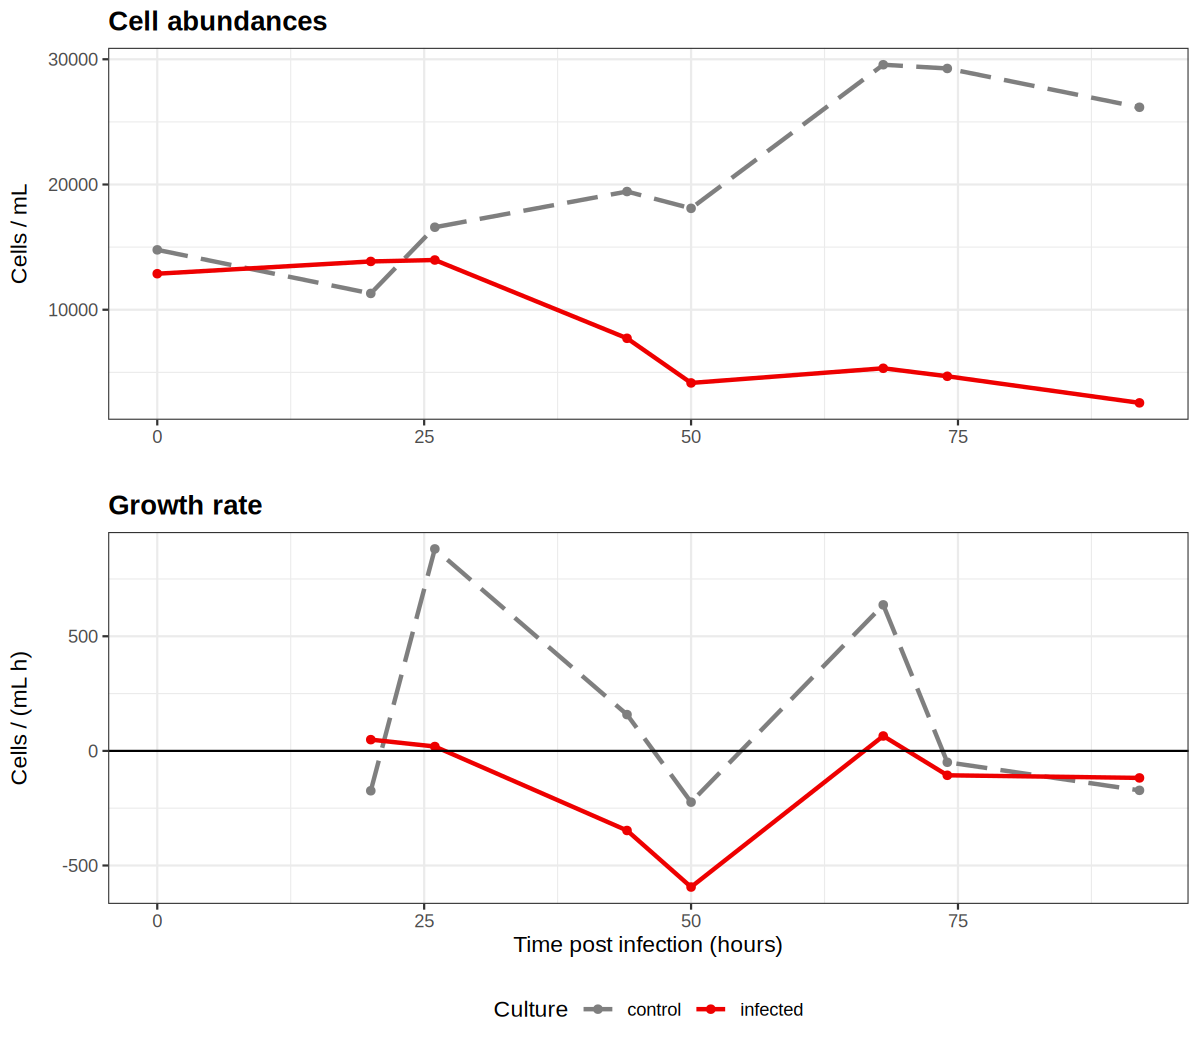

fig5_biomass_rate.png


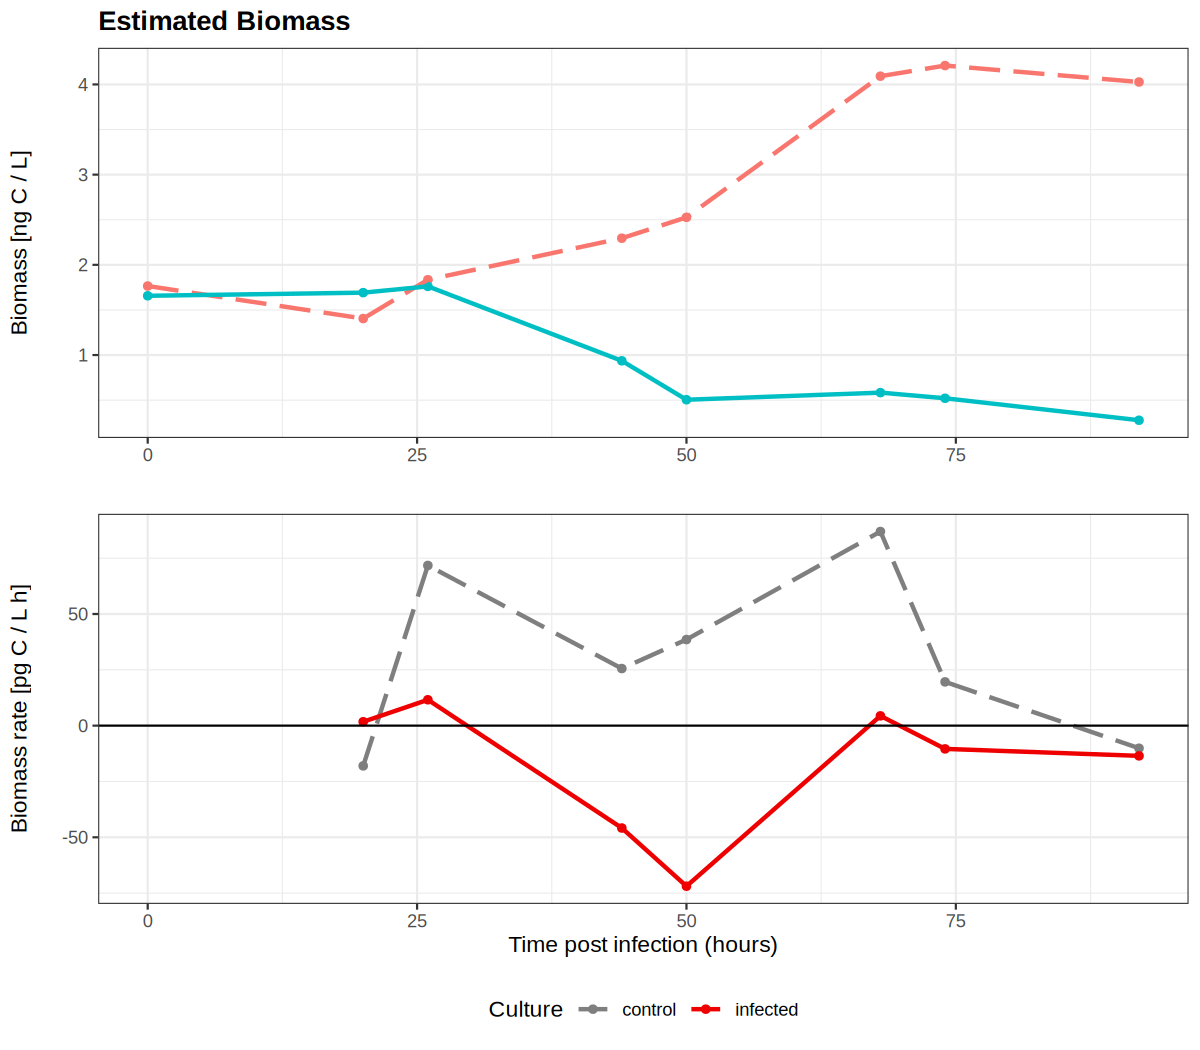

fig5_biovolume_panels.png


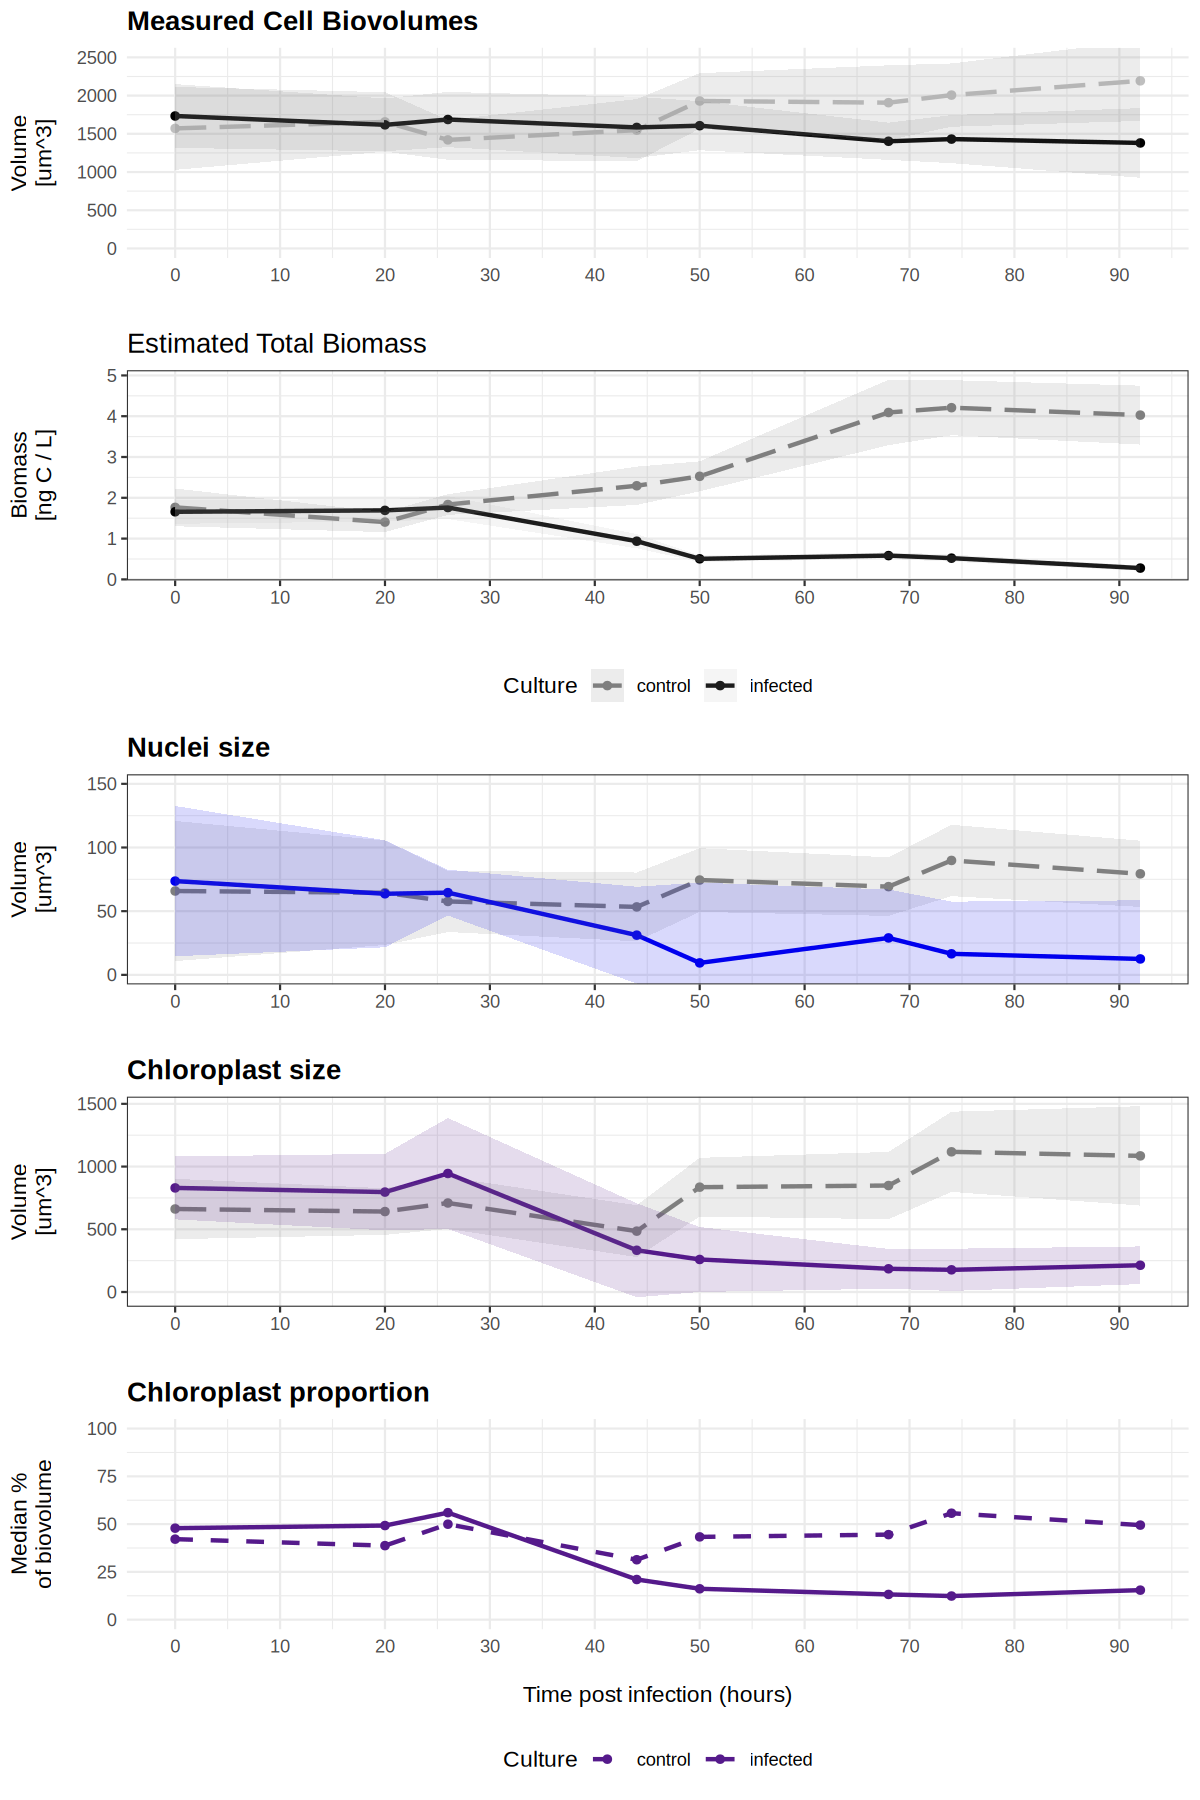

In [ ]:
for f in ["fig5_biovolumes_biomass.png", "fig5_abundance_growth.png",
          "fig5_biomass_rate.png", "fig5_biovolume_panels.png"]:
    print(f)
    display(Image(filename=f"/content/data/{f}"))

## 6. Physiology, titer & cell-fate summary (authors' `plotting_Summary.R`)

Reads `SummaryQuantifications.xlsx` (sheets `Summary`, `Summary_tidy`) and draws the
paper-Figure-1-style abundance/mortality/RNA-spot/viral-titer panels and the Figure-3-style
photosynthetic efficiency (Fv/Fm) panel.

**Documented adaptations:**
1. `BacteriaCounts.xlsx` is **absent from the pinned repository**, so panel E (bacterial
   concentration) is omitted from the Figure-1 group.
2. The committed `SummaryQuantifications.xlsx` contains a single sheet (`Tabelle1`, the wide summary);
   the authors' expected `Summary`/`Summary_tidy` sheets are not in the repository. The tidy
   per-culture table is derived from the wide sheet by reshaping (same values, no recomputation).
3. The authors draw `p3_counts_inf` but define `p1_counts_inf` — a naming bug; the definition is
   renamed to `p3_counts_*` so the bar-plot panel renders as intended.
4. PNG capture helper as above.

**著者の `plotting_Summary.R` を実行します（リポジトリに存在しない `BacteriaCounts.xlsx` のパネル E は省略、変数名バグ `p3_counts_inf` を修正）。**

In [ ]:
pathlib.Path("/content/data/plotting_Summary_adapted.R").write_text(
    '## Adapted from mariescopy/Guinardia_ViralInfection @ ed673c0f6cdad873c5dd3b96d4e7b690bce88b14\n## Original: plotting_Summary.R (GPL-3.0). Adaptations: /content paths; BacteriaCounts.xlsx panel\n## omitted (file absent from repo); p3_counts_inf naming bug fixed; PNG capture helper.\noptions(width = 120)\nsuppressPackageStartupMessages({\n  library(readxl); library(ggplot2); library(data.table); library(RColorBrewer); library(grid)\n})\nsetwd("/content/data")\nsave_grob <- function(p, file, w = 8, h = 9) {\n  png(file, width = w, height = h, units = "in", res = 150)\n  if (inherits(p, "ggplot")) print(p) else grid.draw(p)\n  dev.off()\n}\n\n# Opening the data.\n# ADAPTATION: the committed SummaryQuantifications.xlsx contains a single sheet ("Tabelle1") with the\n# wide summary table; the authors\' "Summary"/"Summary_tidy" sheets are not in the repository. The wide\n# table carries exactly the values used below, and the tidy per-culture table (hours, healthy, dead,\n# spots) is derived from it by reshaping (same numbers, no recomputation).\nguinardia_data <- read_excel("SummaryQuantifications.xlsx", sheet = 1, na = "")\ncolnames(guinardia_data)\nguinardia_tidy <- rbind(\n  data.table(Culture = "infected", hours = guinardia_data$hours,\n             healthy = guinardia_data$inf_healthy, dead = guinardia_data$inf_dead, spots = guinardia_data$inf_spots),\n  data.table(Culture = "control",  hours = guinardia_data$hours,\n             healthy = guinardia_data$con_healthy, dead = guinardia_data$con_dead, spots = guinardia_data$con_spots)\n)\n\n## --- BacteriaCounts.xlsx (panel E) omitted: file not present in the pinned repository. ---\n\n###############################################\n# Figure 1: Abundance, viral titer, mortality, RNA spots\ninf_data <- melt(as.data.table(guinardia_data), id.vars = c("time", "hours"))\ninf_data <- inf_data[variable == "inf_healthy" | variable == "inf_dead" | variable == "inf_spots"]\n\ncon_data <- melt(as.data.table(guinardia_data), id.vars = c("time", "hours"))\ncon_data <- con_data[variable == "con_healthy" | variable == "con_dead" | variable == "con_spots"]\n\n# Line Plots\np1a_abundances <- ggplot(guinardia_data, aes(x = hours)) +\n  geom_line(aes(y = abun_inf), size = 1) +\n  geom_line(aes(y = abun_con), size = 1, linetype = "dashed") +\n  geom_point(aes(y = abun_inf), color = "black", size = 3, alpha = 0.3) +\n  geom_point(aes(y = abun_con), color = "grey50", size = 3, alpha = 0.3) +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  theme_minimal() + theme(legend.position = "none", plot.title = element_text(face = "bold")) +\n  labs(title = "A Cell abundances", x = "", y = "Diatoms / mL")\n\np1b_lines <- ggplot(guinardia_tidy, aes(x = hours, linetype = Culture)) +\n  geom_point(aes(y = healthy), size = 3, alpha = 0.3, color = "magenta4") +\n  geom_line(aes(y = healthy), size = 1, color = "magenta4") +\n  geom_point(aes(y = dead), size = 3, alpha = 0.3, color = "grey75") +\n  geom_line(aes(y = dead), size = 1, color = "grey75") +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_y_continuous(limits = c(0, 100)) +\n  scale_linetype_manual(values = c("dashed", "solid")) +\n  theme_minimal() + theme(legend.position = "none", plot.title = element_text(face = "bold")) +\n  labs(title = "B Subcellular morphologies: Healthy/dead", x = "", y = "% of cells")\n\np1c_lines_RNA <- ggplot(guinardia_tidy, aes(x = hours, linetype = Culture)) +\n  geom_point(aes(y = spots), size = 3, alpha = 0.3, color = "springgreen4") +\n  geom_line(aes(y = spots), size = 1, color = "springgreen4") +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  scale_y_continuous(limits = c(0, 50)) +\n  scale_linetype_manual(values = c("dashed", "solid")) +\n  theme_minimal() + theme(legend.position = "none", plot.title = element_text(face = "bold")) +\n  labs(title = "C Cytosolic RNA spots", x = "", y = "% of cells")\n\np1d_viral_titer <- ggplot(guinardia_data, aes(hours, Viral_titer)) +\n  geom_point(color = "springgreen4", size = 3, alpha = 0.3) +\n  geom_line(color = "springgreen4", size = 1) +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  theme_minimal() + theme(legend.position = "none", plot.title = element_text(face = "bold")) +\n  labs(title = "D Extracellular infectious RNA viruses", x = "", y = "Viral titer / mL")\n\n# Figure 1-style group (panel E omitted — BacteriaCounts.xlsx absent)\nsave_grob(rbind(ggplotGrob(p1a_abundances),\n                ggplotGrob(p1b_lines),\n                ggplotGrob(p1c_lines_RNA),\n                ggplotGrob(p1d_viral_titer),\n                size = "last"),\n          "/content/data/fig1_summary.png")\n\n################################################################\n# Figure 3: Photosynthetic efficiency\np2b_FvFm <- ggplot(guinardia_data, aes(x = hours)) +\n  geom_line(aes(y = Fv_Fm_inf), size = 1) +\n  geom_line(aes(y = Fv_Fm_con), size = 1, linetype = "dashed") +\n  geom_hline(yintercept = 0.6, color = "grey25", size = 0.3) +\n  scale_x_continuous(breaks = c(seq(0, 92, 10))) +\n  theme_minimal() +\n  labs(title = "Photosynthetic efficiency", y = "Fv/Fm", x = "")\nsave_grob(p2b_FvFm, "/content/data/fig3_FvFm.png", w = 8, h = 4)\n\n# Bar plots (naming bug fixed: the original draws p3_counts_inf but defines p1_counts_inf)\np3_counts_inf <- ggplot(inf_data, aes(x = time, y = value, fill = variable)) +\n  geom_bar(stat = "identity", position = \'dodge\') +\n  scale_fill_manual(values = c("magenta4", "grey75", "springgreen4")) +\n  scale_x_discrete(labels = unique(guinardia_data$hours)) +\n  theme_minimal() + theme(legend.position = "none") +\n  labs(y = "Percentage of cells (%)", x = "", title = "A  Infected culture")\n\np3_counts_con <- ggplot(con_data, aes(x = time, y = value, fill = variable)) +\n  geom_bar(stat = "identity", position = \'dodge\') +\n  scale_fill_manual(values = c("magenta4", "grey75", "springgreen4"), name = "",\n                    labels = c("healthy", "dead", "RNA spots visible")) +\n  scale_x_discrete(labels = unique(guinardia_data$hours)) +\n  theme_minimal() + theme(legend.position = "bottom") +\n  labs(x = "Time post infection (hours)", y = "Percentage of cells (%)", title = "B  Control culture")\n\nsave_grob(rbind(ggplotGrob(p3_counts_inf), ggplotGrob(p3_counts_con), size = "last"),\n          "/content/data/fig1_cell_fates.png")\n\ncat("Summary figures written.\\n")', encoding="utf-8")
r = subprocess.run(["Rscript", "/content/data/plotting_Summary_adapted.R"], capture_output=True, text=True, timeout=900)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("plotting_Summary.R (adapted) failed; see output above.")

 [1] "time"        "hours"       "abun_con"    "abun_inf"    "Fv_Fm_con"   "Fv_Fm_inf"   "Viral_titer" "inf_healthy"
 [9] "inf_dead"    "inf_spots"   "con_healthy" "con_dead"    "con_spots"  
null device 
          1 
null device 
          1 
null device 
          1 
Summary figures written.



Rendered summary panels:

**サマリーパネル（図 1・図 3 相当）。**

fig1_summary.png


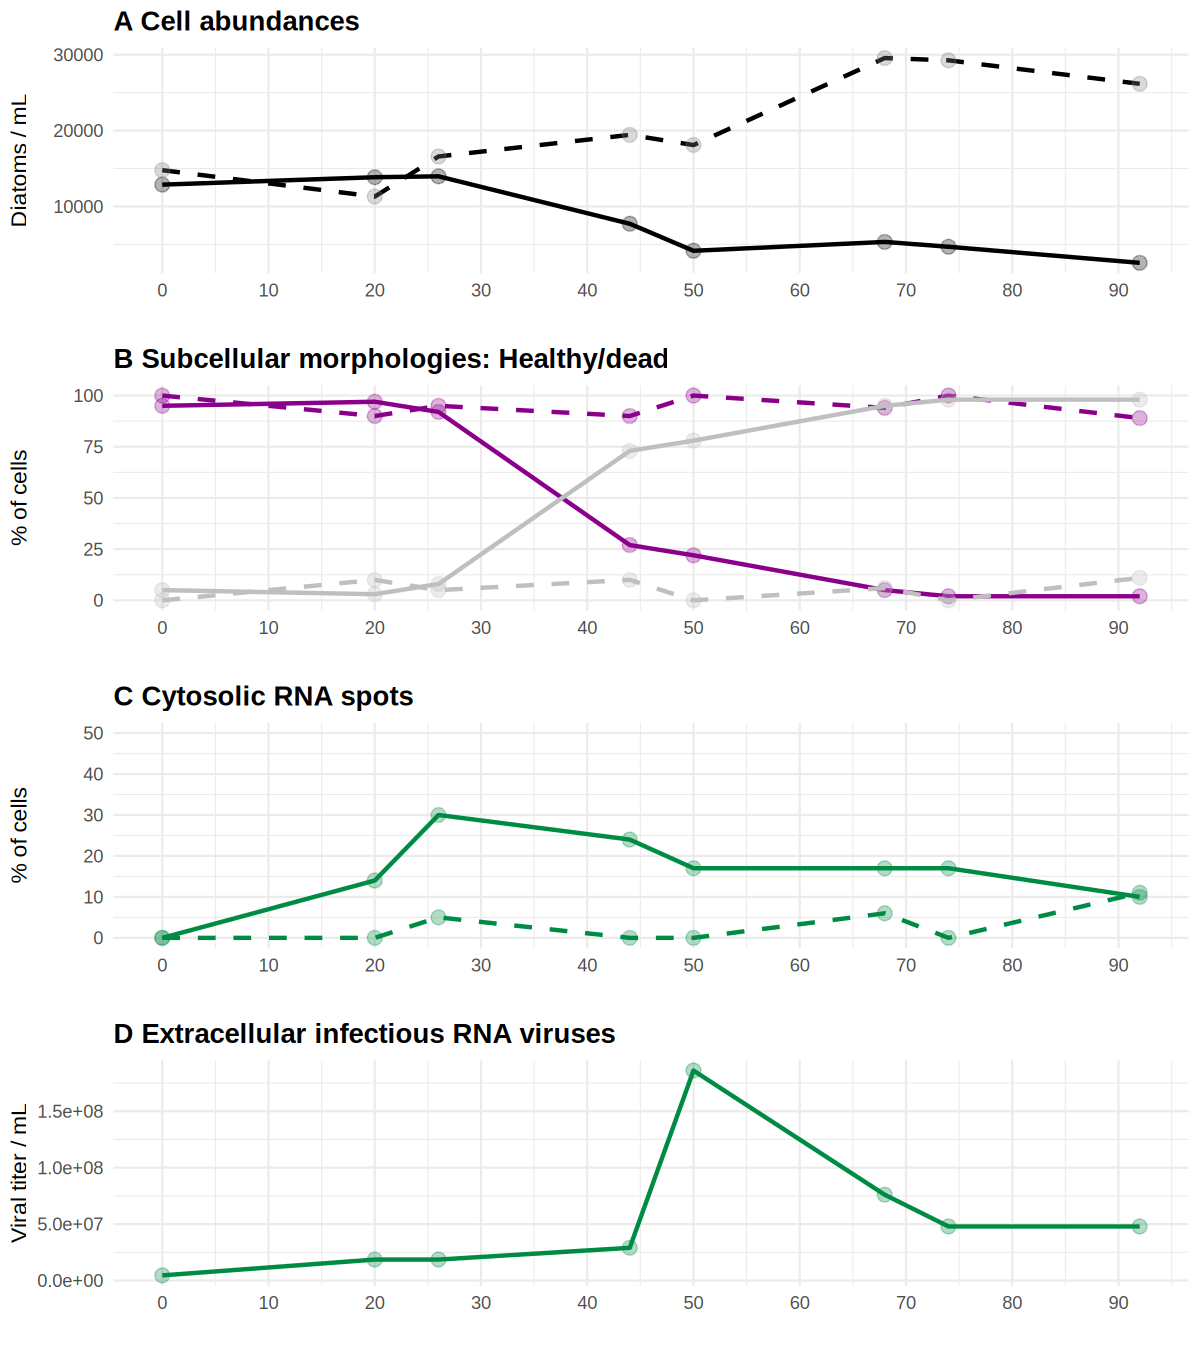

fig3_FvFm.png


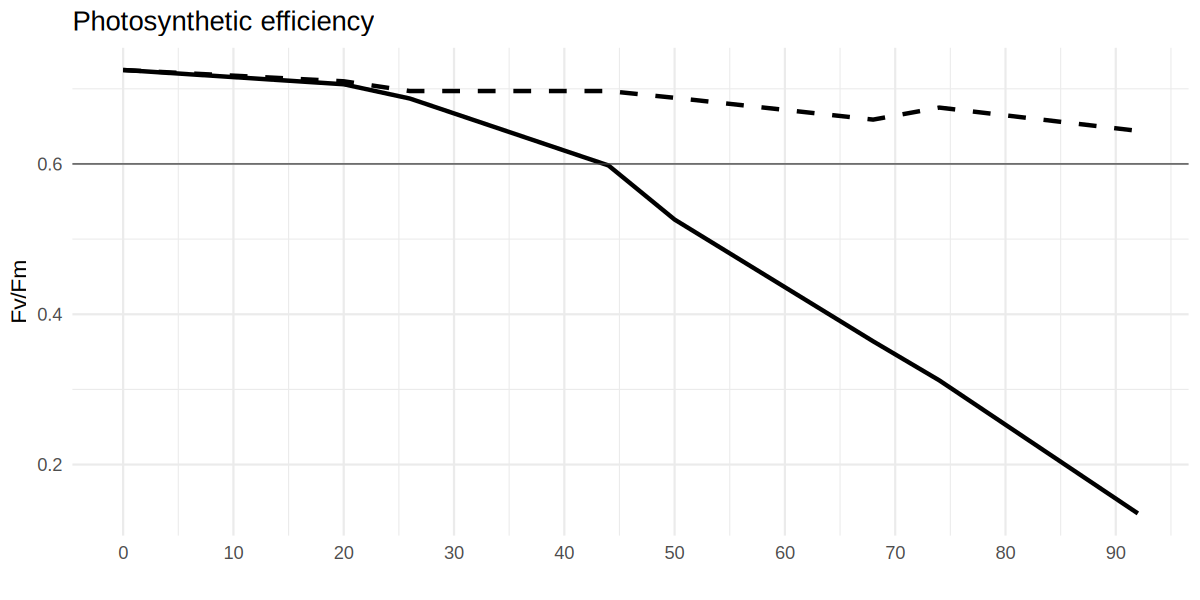

fig1_cell_fates.png


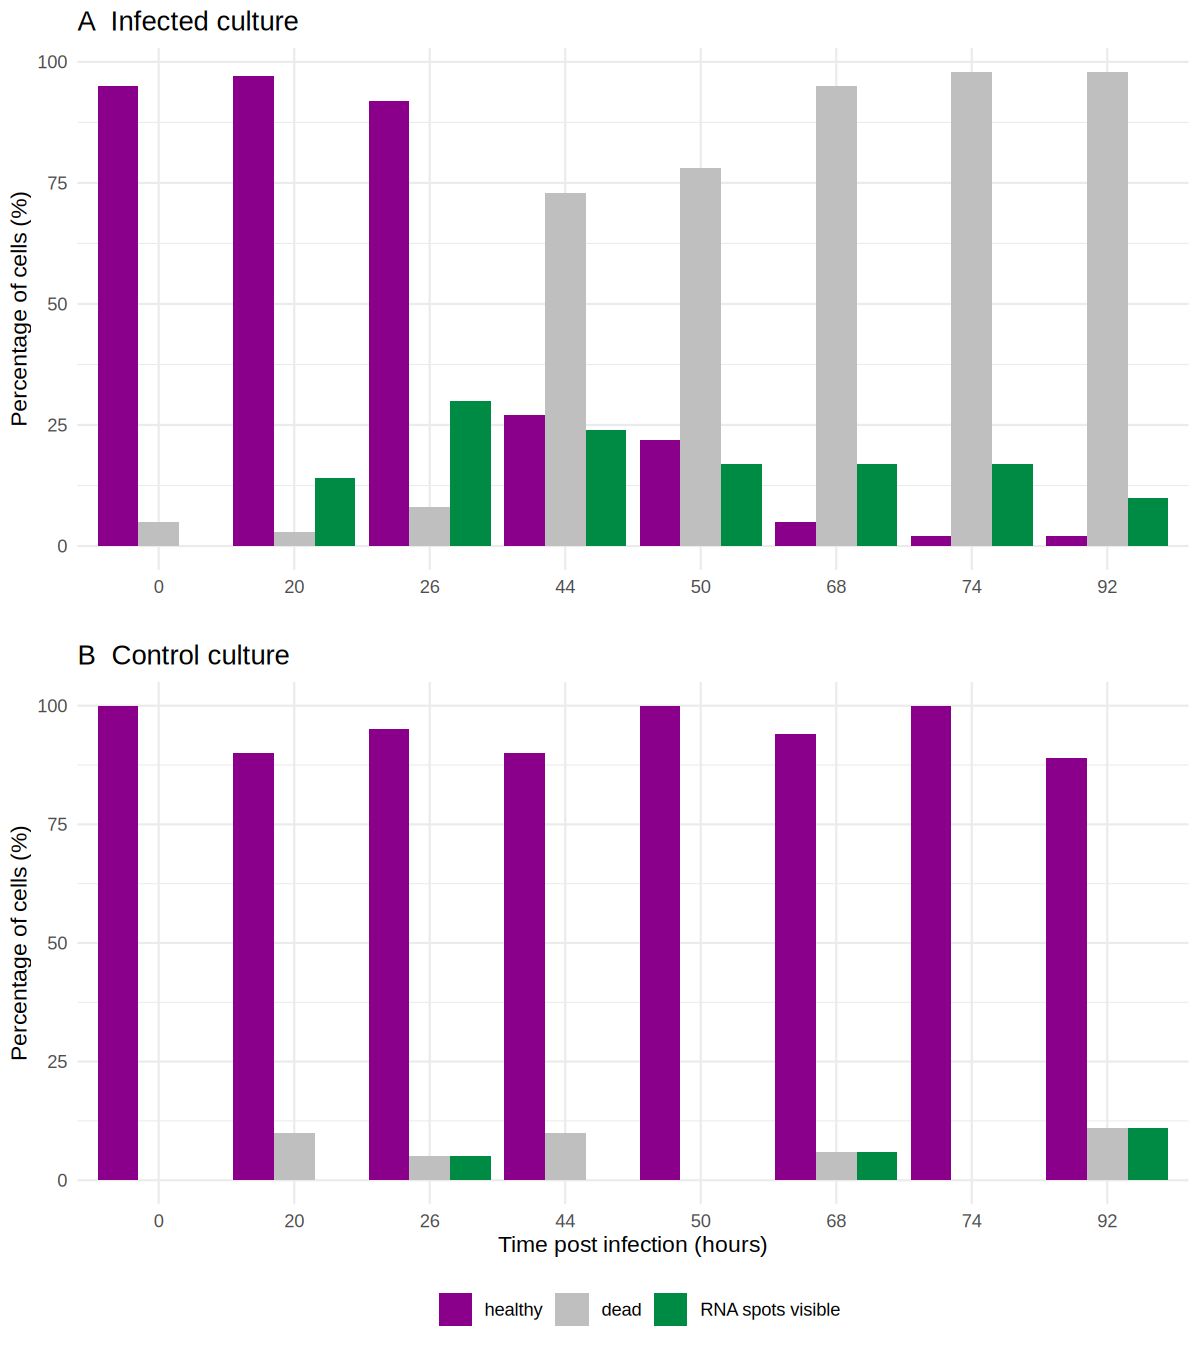

In [ ]:
for f in ["fig1_summary.png", "fig3_FvFm.png", "fig1_cell_fates.png"]:
    print(f)
    display(Image(filename=f"/content/data/{f}"))

## 7. Key numbers from the tables

A few headline values extracted from the authors' tables so the plots can be checked against the
paper's reported infection dynamics (virion peak ~50 hpi; biomass decline in the infected culture;
Fv/Fm drop).

**主要な数値（著者テーブルから抽出）。**

In [ ]:
script = r"""
options(width = 120)
d <- readxl::read_excel("/content/data/SummaryQuantifications.xlsx", sheet = 1, na = "")
cat("Viral titer peak:", max(d$Viral_titer, na.rm = TRUE),
    "at hpi =", d$hours[which.max(d$Viral_titer)], "\n")
cat("Fv/Fm infected: first =", d$Fv_Fm_inf[1], " last =", d$Fv_Fm_inf[nrow(d)], "\n")
cat("Fv/Fm control:  first =", d$Fv_Fm_con[1],  " last =", d$Fv_Fm_con[nrow(d)],  "\n")
b <- readxl::read_excel("/content/data/Biovolumes_biomass.xlsx", sheet = 2, na = "")
bl <- b[b$Culture == "infected", ]
bc <- b[b$Culture == "control", ]
cat("Biomass ng C/L infected: first =", bl$Biomass_ngLiter[1], " last =", bl$Biomass_ngLiter[nrow(bl)], "\n")
cat("Biomass ng C/L control:  first =", bc$Biomass_ngLiter[1], " last =", bc$Biomass_ngLiter[nrow(bc)], "\n")
cat("Cell abundance infected (first/last):", bl$Abundance_count[1], "/", bl$Abundance_count[nrow(bl)], "\n")
"""
pathlib.Path("/content/data/key_numbers.R").write_text(script)
r = subprocess.run(["Rscript", "/content/data/key_numbers.R"], capture_output=True, text=True, timeout=300)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-2000:]); raise RuntimeError("Key-number extraction failed.")

Viral titer peak: 1.86e+08 at hpi = 50 
Fv/Fm infected: first = 0.725  last = 0.135 
Fv/Fm control:  first = 0.725  last = 0.644 
Biomass ng C/L infected: first = 1.656993  last = 0.2772672 
Biomass ng C/L control:  first = 1.765035  last = 4.026936 
Cell abundance infected (first/last): 12877 / 2563 



## 8. Interpretation, differences from the paper, validation record

**What was reproduced (executed in this notebook):** the authors' own R analysis/plotting scripts
(`plotting_3DMorphometry.R`, `plotting_Biovolumes.R`, `plotting_Summary.R` @ `ed673c0`) re-run on the
authors' own intermediate result tables, regenerating figure groups in the style of paper
Figures 1, 3, 4 and 5. Expected qualitative agreement: chloroplast rounding and sphericity changes in
the infected culture, declining infected-culture biomass, Fv/Fm drop, and a viral-titer peak mid-infection.

**Differences / limitations:**
- The upstream pipeline (Leica LIF acquisition at BioStudies S-BIAD534, FIJI 3D morphometry macros
  `GuinardiaInfection_3DMorphometry.ijm` / `MontageFromLIF.ijm`) is **not** re-run — this notebook starts
  from the authors' Excel outputs. Single-example execution does not verify the paper's dataset-level claims.
- Sections whose input files are absent from the pinned repository were omitted and are labeled:
  per-timepoint t-tests (`3D_Morphometry_noNA.xlsx`) and bacterial counts (`BacteriaCounts.xlsx`).
- Two script-level bugs in the author code (`p3_counts_inf` naming; cross-script `p2b_FvFm` reference)
  were fixed as documented; paths were redirected to `/content/data`.
- The study flow record (PhenoPaper, `complete_from_fulltext`, reviewStatus `unverified`) was used as
  research guidance only; all executed logic here comes from the pinned author code.

**検証レコード:** 著者スクリプト（pinned commit）を著者の中間テーブルに対して再実行しました。生画像・FIJI 段階は対象外で、リポジトリに無い入力に依存するセクションは省略しています。

**References:**
- Walde et al. 2022, bioRxiv 2022.09.06.505714 — https://doi.org/10.1101/2022.09.06.505714
- Author code (GPL-3.0): https://github.com/mariescopy/Guinardia_ViralInfection @ `ed673c0f6cdad873c5dd3b96d4e7b690bce88b14`
- Raw/processed images: BioStudies S-BIAD534 — https://www.ebi.ac.uk/biostudies/studies/S-BIAD534